<a href="https://colab.research.google.com/github/jordano-crt/TelecomX-parte-2-challenge/blob/main/TelecomX_parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛠️ Preparacion de datos

# Extraccion de archivo tratado
- Se usara el mismo archivo que se normalizo en la parte 1 del challenge Telecom

In [1]:
import pandas as pd

In [2]:
datos = pd.read_csv('datos_normalizados.csv')

In [5]:

# Dimensiones del dataset
print("Dimensiones del dataset:", datos.shape)

# Primeras filas
print("\nPrimeras filas del dataset:")
display(datos.head())

# Información general de columnas
print("\nInformación del dataset:")
print(datos.info())

# Verificar valores nulos
print("\nValores nulos por columna:")
print(datos.isnull().sum())

# Distribución de la variable objetivo (Churn)
print("\nDistribución de Churn:")
print(datos["Churn"].value_counts(normalize=True))

Dimensiones del dataset: (7032, 22)

Primeras filas del dataset:


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   int64  
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   object 
 5   customer.Dependents        7032 non-null   object 
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   object 
 8   phone.MultipleLines        7032 non-null   object 
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   object 
 11  internet.OnlineBackup      7032 non-null   object 
 12  internet.DeviceProtection  7032 non-null   object 
 13  internet.TechSupport  

# Eliminacion de columnas irrelevantes

In [7]:
# Eliminar columnas que no aportan al análisis (ejemplo: ID único del cliente)
df = datos.drop(columns=["customerID"])

# Confirmar que se eliminó
print("Columnas actuales del dataset:", datos.columns.tolist())
print("\nDimensiones después de eliminar columnas irrelevantes:", datos.shape)

Columnas actuales del dataset: ['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias']

Dimensiones después de eliminar columnas irrelevantes: (7032, 22)


# Encoding

In [8]:
# Identificar columnas categóricas (object o category)
categorical_cols = datos.select_dtypes(include=["object"]).columns
print("Columnas categóricas detectadas:", categorical_cols.tolist())

# Aplicar One-Hot Encoding usando pandas get_dummies
datos_encoded = pd.get_dummies(datos, columns=categorical_cols, drop_first=True)

# Confirmar transformación
print("\nDimensiones después del encoding:", datos_encoded.shape)
print("Ejemplo de columnas después del encoding:", datos_encoded.columns[:15].tolist())

# Visualizar primeras filas
display(datos_encoded.head())

Columnas categóricas detectadas: ['customerID', 'customer.gender', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod']

Dimensiones después del encoding: (7032, 7063)
Ejemplo de columnas después del encoding: ['Churn', 'customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE', 'customerID_0014-BMAQU', 'customerID_0015-UOCOJ', 'customerID_0016-QLJIS']


,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,2.186667,False,False,False,False,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,1.996667,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,2.463333,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
3,1,1,13,98.0,1237.85,3.266667,False,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,1,3,83.9,267.40,2.796667,False,False,False,True,...,False,True,False,False,False,False,True,False,False,True


# Verificación de la proporcion de cancelación

Cantidad de clientes por clase:
Churn
0    5163
1    1869
Name: count, dtype: int64

Proporción de clientes por clase:
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


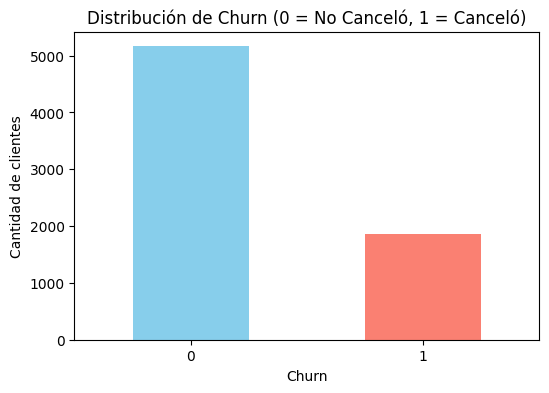

In [9]:
# Conteo de clientes que cancelaron (1) vs los que permanecieron (0)
churn_counts = datos["Churn"].value_counts()
churn_ratio = datos["Churn"].value_counts(normalize=True)

print("Cantidad de clientes por clase:")
print(churn_counts)

print("\nProporción de clientes por clase:")
print(churn_ratio)

# Visualización rápida
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
churn_counts.plot(kind='bar', color=["skyblue","salmon"])
plt.title("Distribución de Churn (0 = No Canceló, 1 = Canceló)")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)
plt.show()

# Balanceo de clases

In [10]:
# ==========================
# 📌 Balanceo de clases con SMOTE (opcional)
# ==========================

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Definir variable objetivo y features
X = datos_encoded.drop("Churn", axis=1)
y = datos_encoded["Churn"]

# Dividir en train/test antes de balancear
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Distribución original en TRAIN:")
print(y_train.value_counts(normalize=True))

# Aplicar SMOTE solo en datos de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nDistribución después de aplicar SMOTE en TRAIN:")
print(y_train_bal.value_counts(normalize=True))


Distribución original en TRAIN:
Churn
0    0.734254
1    0.265746
Name: proportion, dtype: float64

Distribución después de aplicar SMOTE en TRAIN:
Churn
1    0.5
0    0.5
Name: proportion, dtype: float64


# Normalización o Estandariazción

In [11]:
from sklearn.preprocessing import StandardScaler

# Identificar columnas numéricas (excluyendo la variable objetivo)
numeric_cols = X_train.select_dtypes(include=["int64","float64"]).columns
print("Columnas numéricas a escalar:", numeric_cols.tolist())

# Inicializar el escalador
scaler = StandardScaler()

# Ajustar en TRAIN y transformar TRAIN y TEST
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("\nEstandarización aplicada. Ejemplo de datos escalados:")
display(X_train_scaled.head())

Columnas numéricas a escalar: ['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias']

Estandarización aplicada. Ejemplo de datos escalados:


,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
4314,-0.436924,-0.628770,0.922832,-0.338930,0.922832,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
1935,-0.436924,0.667450,-1.480460,-0.598522,-1.480460,False,False,False,False,False,...,True,False,True,False,True,False,True,False,False,False
4726,-0.436924,-1.033839,-1.470516,-0.937264,-1.470516,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
5709,2.288728,0.869984,0.839960,1.159293,0.839960,False,False,False,False,False,...,False,False,False,True,False,False,True,False,True,False
3416,-0.436924,1.518094,1.302386,2.175890,1.302386,False,False,False,False,False,...,False,True,False,True,False,True,True,True,False,False


# 🎯 Correlación y Selección de Variables

# Analisis de correlación

Correlación de variables con Churn:

Churn                                     1.000000
internet.InternetService_Fiber optic      0.307463
account.PaymentMethod_Electronic check    0.301455
Cuentas_Diarias                           0.192858
account.Charges.Monthly                   0.192858
account.PaperlessBilling_Yes              0.191454
customer.SeniorCitizen                    0.150541
internet.StreamingTV_Yes                  0.063254
internet.StreamingMovies_Yes              0.060860
phone.MultipleLines_Yes                   0.040033
customerID_8854-CCVSQ                     0.019822
customerID_8844-TONUD                     0.019822
customerID_8837-VVWLQ                     0.019822
customerID_8849-GYOKR                     0.019822
customerID_8808-ELEHO                     0.019822
Name: Churn, dtype: float64


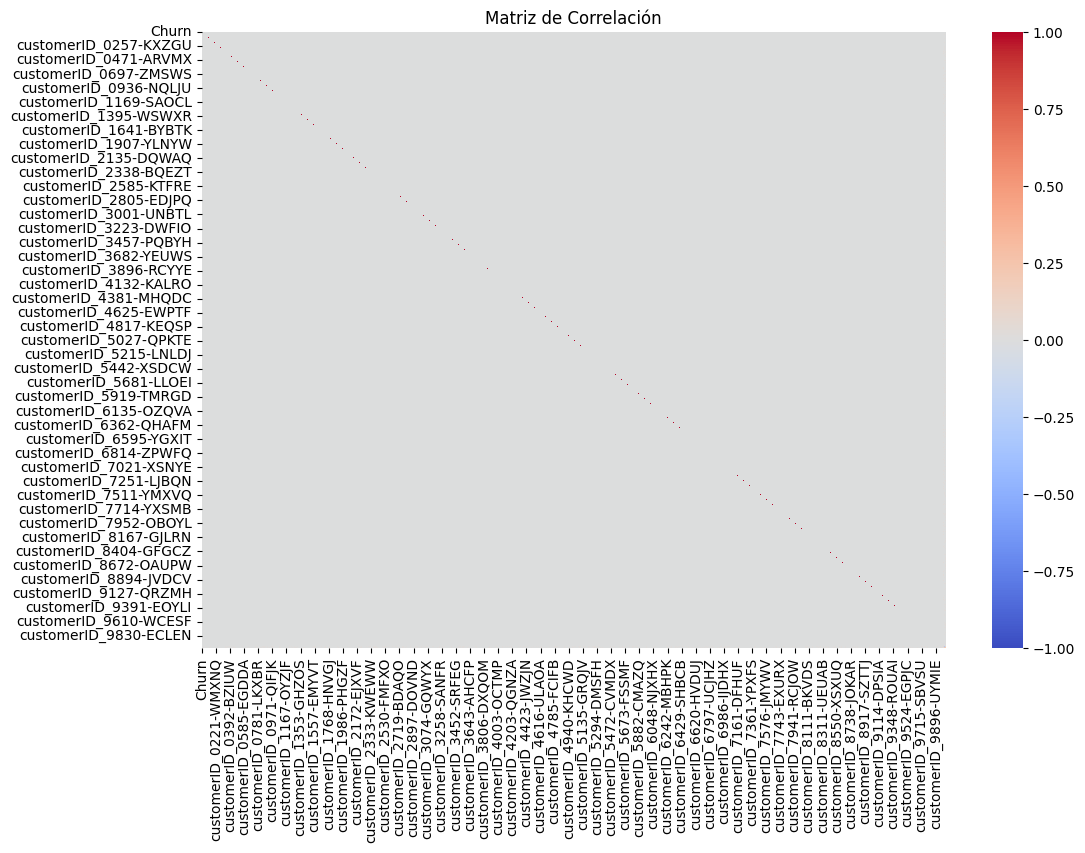

/tmp/ipython-input-2576260907.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_corr.values, y=churn_corr.index, palette="coolwarm")


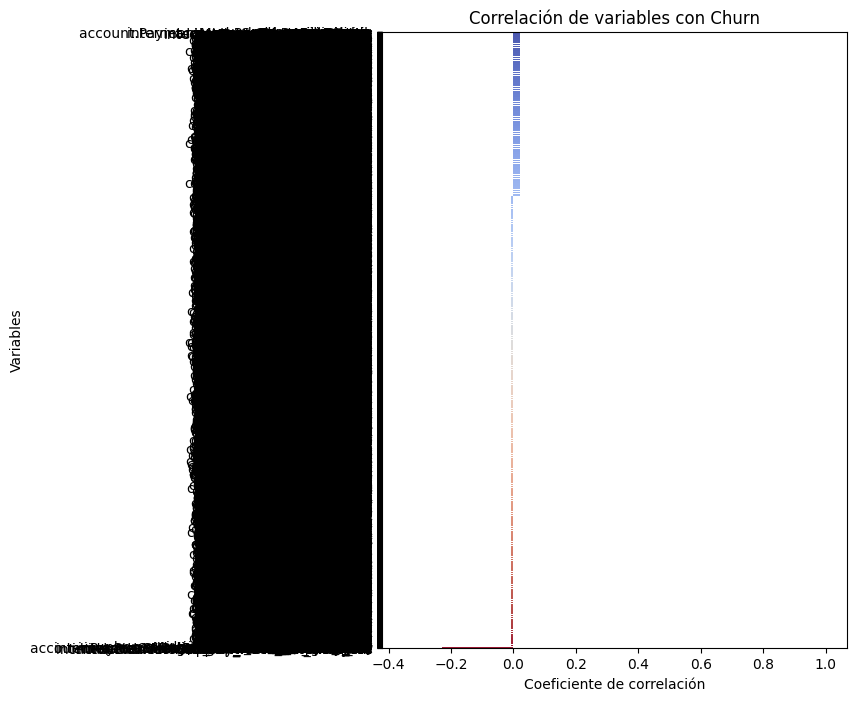

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular matriz de correlación solo para variables numéricas
corr_matrix = datos_encoded.corr()

# Correlación de cada variable con Churn (ordenada)
churn_corr = corr_matrix["Churn"].sort_values(ascending=False)
print("Correlación de variables con Churn:\n")
print(churn_corr.head(15))  # Top 15 más correlacionadas

# Visualización con mapa de calor
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, cbar=True)
plt.title("Matriz de Correlación")
plt.show()

# Visualizar solo correlaciones con Churn
plt.figure(figsize=(6,8))
sns.barplot(x=churn_corr.values, y=churn_corr.index, palette="coolwarm")
plt.title("Correlación de variables con Churn")
plt.xlabel("Coeficiente de correlación")
plt.ylabel("Variables")
plt.show()

Analisis dirigido

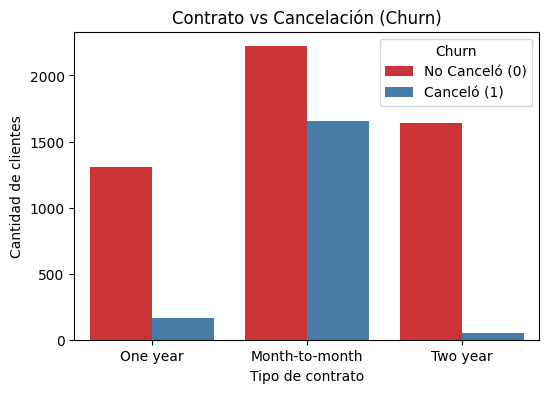

/tmp/ipython-input-2482655396.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="account.Charges.Total", data=datos, palette="Set2")


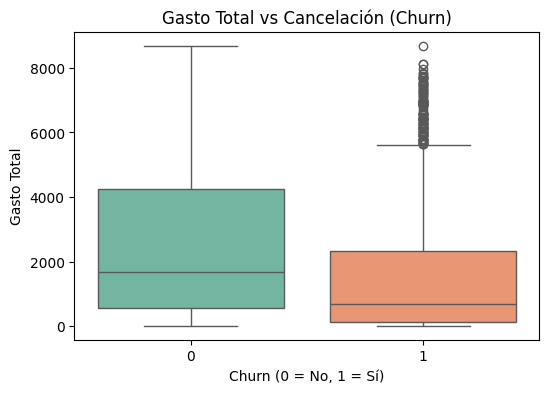

/tmp/ipython-input-2482655396.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="Churn", y="account.Charges.Total", data=datos, jitter=True, alpha=0.4, palette="Set1")


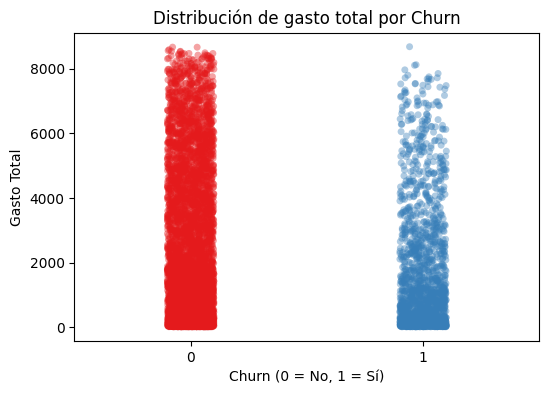

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Contrato vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x="account.Contract", hue="Churn", data=datos, palette="Set1")
plt.title("Contrato vs Cancelación (Churn)")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")
plt.legend(title="Churn", labels=["No Canceló (0)", "Canceló (1)"])
plt.show()

# 2. Gasto total vs Churn (Boxplot)
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="account.Charges.Total", data=datos, palette="Set2")
plt.title("Gasto Total vs Cancelación (Churn)")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Gasto Total")
plt.show()

# 3. Gasto total vs Churn (Scatter con jitter)
plt.figure(figsize=(6,4))
sns.stripplot(x="Churn", y="account.Charges.Total", data=datos, jitter=True, alpha=0.4, palette="Set1")
plt.title("Distribución de gasto total por Churn")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Gasto Total")
plt.show()


# Separacion de datos

In [15]:
# ==========================
# 📌 Separación de datos en Train y Test
# ==========================

from sklearn.model_selection import train_test_split

# Variables predictoras (X) y objetivo (y)
X = datos_encoded.drop("Churn", axis=1)
y = datos_encoded["Churn"]

# División 70/30 (train/test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)
print("\nDistribución de Churn en TRAIN:")
print(y_train.value_counts(normalize=True))
print("\nDistribución de Churn en TEST:")
print(y_test.value_counts(normalize=True))


Tamaño del conjunto de entrenamiento: (4922, 7062)
Tamaño del conjunto de prueba: (2110, 7062)

Distribución de Churn en TRAIN:
Churn
0    0.734254
1    0.265746
Name: proportion, dtype: float64

Distribución de Churn en TEST:
Churn
0    0.734123
1    0.265877
Name: proportion, dtype: float64


# Creacion de modelos

In [16]:
# ==========================
# 📌 Creación de Modelos Predictivos
# ==========================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# --- Modelo 1: Regresión Logística (con normalización) ---
# Escalamos los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# --- Modelo 2: Random Forest (sin normalización) ---
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

print("✅ Modelos entrenados correctamente:")
print("- Regresión Logística (con normalización)")
print("- Random Forest (sin normalización)")


✅ Modelos entrenados correctamente:
- Regresión Logística (con normalización)
- Random Forest (sin normalización)


# Evaluacion de modelos

🔹 Modelo 1: Regresión Logística (con normalización)
📊 Evaluación del modelo: LogisticRegression

🔹 Resultados en TEST:
Exactitud (Accuracy): 0.7773
Precisión: 0.6888
Recall: 0.2959
F1-score: 0.4140

📑 Classification Report (Test):
              precision    recall  f1-score   support

           0       0.79      0.95      0.86      1549
           1       0.69      0.30      0.41       561

    accuracy                           0.78      2110
   macro avg       0.74      0.62      0.64      2110
weighted avg       0.76      0.78      0.74      2110



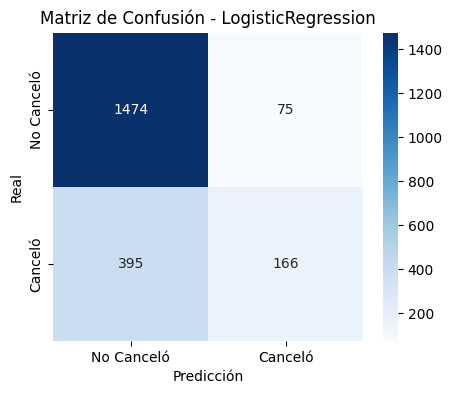


🔹 Modelo 2: Random Forest (sin normalización)
📊 Evaluación del modelo: RandomForestClassifier

🔹 Resultados en TEST:
Exactitud (Accuracy): 0.7919
Precisión: 0.6572
Recall: 0.4545
F1-score: 0.5374

📑 Classification Report (Test):
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1549
           1       0.66      0.45      0.54       561

    accuracy                           0.79      2110
   macro avg       0.74      0.68      0.70      2110
weighted avg       0.78      0.79      0.78      2110



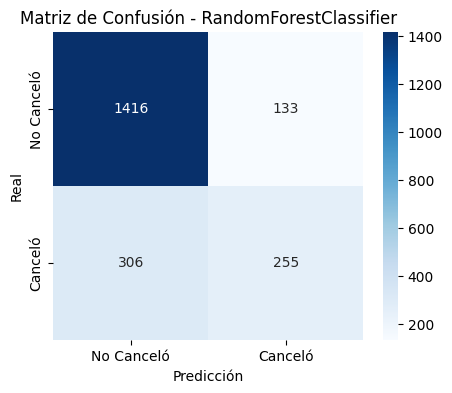

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluar_modelo(modelo, X_train, y_train, X_test, y_test, normalizado=False):
    """Función para entrenar, predecir y mostrar métricas"""

    # Predicciones
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    # Métricas en TEST
    acc = accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test)
    rec = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)

    print("="*50)
    print(f"📊 Evaluación del modelo: {modelo.__class__.__name__}")
    print("="*50)
    print("\n🔹 Resultados en TEST:")
    print(f"Exactitud (Accuracy): {acc:.4f}")
    print(f"Precisión: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Reporte detallado
    print("\n📑 Classification Report (Test):")
    print(classification_report(y_test, y_pred_test))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Canceló","Canceló"], yticklabels=["No Canceló","Canceló"])
    plt.title(f"Matriz de Confusión - {modelo.__class__.__name__}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

    return acc, prec, rec, f1


# --- Evaluar Regresión Logística ---
print("🔹 Modelo 1: Regresión Logística (con normalización)")
eval_log = evaluar_modelo(log_reg, X_train_scaled, y_train, X_test_scaled, y_test)

# --- Evaluar Random Forest ---
print("\n🔹 Modelo 2: Random Forest (sin normalización)")
eval_rf = evaluar_modelo(rf, X_train, y_train, X_test, y_test)


# Análisis de la Importancia de las Variables

# Conclusión